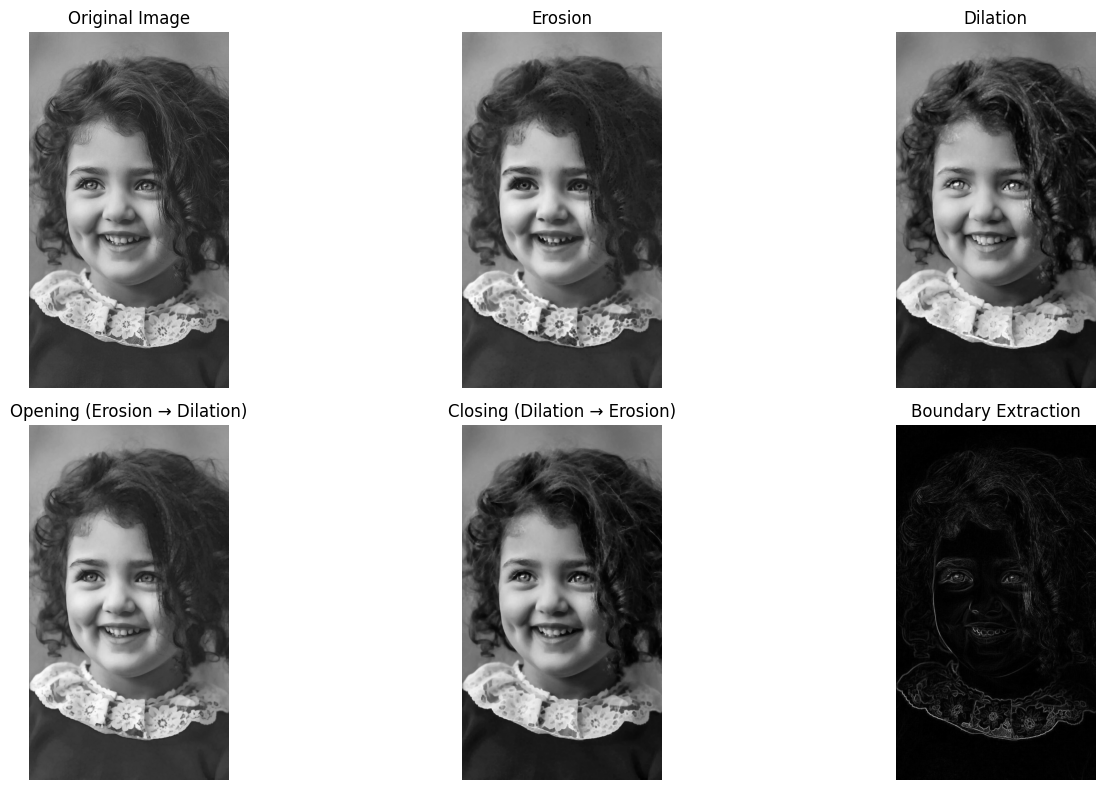

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1️⃣ Read Image ---
img = cv2.imread('pk.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("❌ Image not found. Please make sure 'pk.jpg' is in the same folder.")

# --- 2️⃣ Define Structuring Element ---
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), np.uint8)

# --- 3️⃣ Apply Morphological Operations ---
erosion = cv2.erode(img, kernel, iterations=1)
dilation = cv2.dilate(img, kernel, iterations=1)

# Opening = Erosion followed by Dilation (removes small noise)
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

# Closing = Dilation followed by Erosion (fills small holes)
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

# Boundary Extraction = Original - Eroded Image
boundary = cv2.subtract(img, erosion)

# --- 4️⃣ Display Results ---
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(erosion, cmap='gray')
plt.title('Erosion')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(dilation, cmap='gray')
plt.title('Dilation')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(opening, cmap='gray')
plt.title('Opening (Erosion → Dilation)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(closing, cmap='gray')
plt.title('Closing (Dilation → Erosion)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(boundary, cmap='gray')
plt.title('Boundary Extraction')
plt.axis('off')

plt.tight_layout()
plt.show()


In [4]:
import cv2
import numpy as np

# Read image
original = cv2.imread('pk.jpg', cv2.IMREAD_COLOR)
if original is None:
    raise FileNotFoundError("Image 'pk.jpg' not found. Please check the file path.")

cv2.imshow('Original', original)

#--------------------<Canny Edge Detection>--------------------#
edges = cv2.Canny(original,100,200)
cv2.imshow('Edge', edges)

#--------------------<Threshold-Based Image Segmentation>--------------------#
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
# Apply thresholding
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
# Display thresholded image
cv2.imshow('thresholded', thresh)

#--------------------<Region-Based Image Segmentation>--------------------#
def region_growing(img, seed, threshold = 20):
    height, width =img.shape
    print(img.shape)
    mask = np.zeros((height, width), dtype=np.uint8)
    seed_value = img[seed[1], seed[0]]
    to_process = [seed]
    while to_process:
        x, y = to_process.pop()
        if mask[y, x] == 0:
            mask[y, x] = 255
            for dx,dy in [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]:
                nx, ny = x+dx, y+dy
                if 0<=nx<width and 0<=ny <height:
                    if mask[ny, nx] == 0 and abs(int(img[ny, nx]) - int(seed_value)) < threshold:
                        to_process.append((nx, ny))
    return mask

img = cv2.imread('pk.jpg', cv2.IMREAD_GRAYSCALE)
seed = (150, 80)
segmented_region = region_growing(img ,seed, threshold=30)
# cv2.imshow('original', original)
cv2.imshow('Segmented Region', segmented_region)


cv2.waitKey(0)
cv2.destroyAllWindows()

(1280, 720)
